Question 1 a

In [28]:
import math
import numpy as np
import matplotlib.pyplot as plt

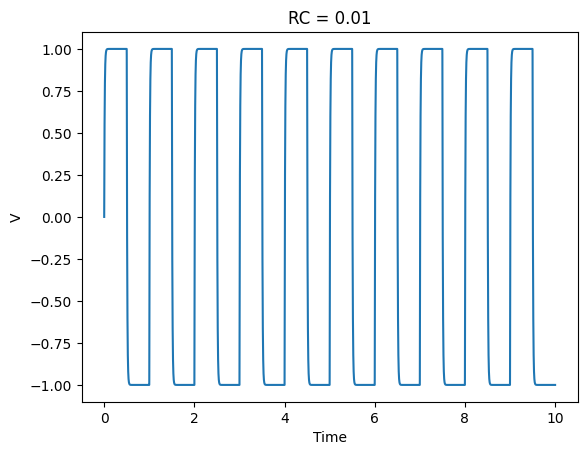

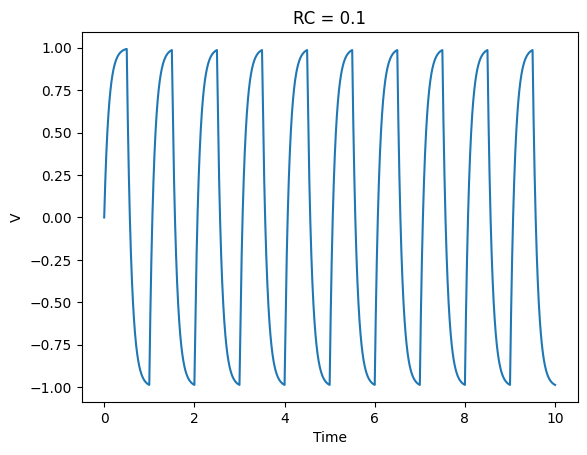

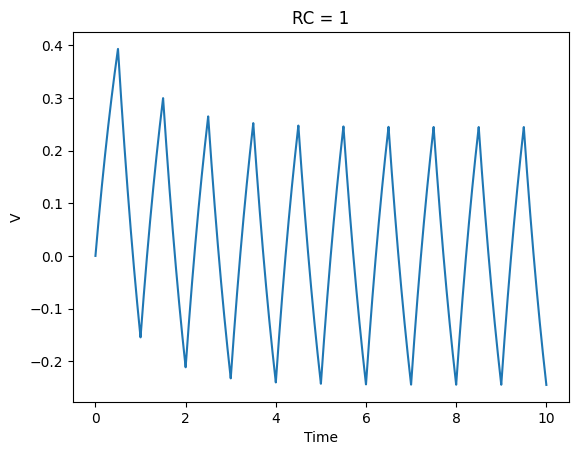

In [29]:
#function for dVout/dt
def f(RC, Vin, Vout):
    return 1/(RC)*(Vin - Vout)

#function for V_in - piecewise function in assignment description
def V_in(t):
    #round down to nearest 2*t
    if math.floor(2*t) % 2 == 0:
        return 1
    else:
        return -1

#function for RK4 method
def RK4(f, t1, h, num_steps, RC, Vout_0):
    #initialize variables and create output array
    solution = [(t1, Vout_0)]
    t = t1
    Vout = Vout_0

    for _ in range(num_steps):
        #complete the RK4 steps
        k1 = h*f(RC, V_in(t), Vout)
        k2 = h * f(RC, V_in(t+0.5*h), Vout+0.5*k1)
        k3 = h* f(RC, V_in(t+0.5*h), Vout+0.5*k2)
        k4 = h * f(RC, V_in(t+h), Vout+k3)

        #update Vout and t
        Vout += (k1 + 2*k2 + 2*k3 +k4)/6
        t += h
        #add the result for this iteration to the solution array
        solution.append((t, Vout))

    return solution

#initialize variables
RC1 = 0.01
t1 = 0
t2 = 10
Vout_0 = 0
h = 0.001
num_steps = 10000

#get the Rk4 solution
sol = RK4(f, t1, h, num_steps, RC1, Vout_0)

t_vals1 = [t for t, _ in sol]
Vout_vals1 = [Vout for _, Vout in sol]

#plot RC = 0.01 result
plt.plot(t_vals1, Vout_vals1)
plt.xlabel("Time")
plt.ylabel("V")
plt.title("RC = 0.01")
plt.show()

#update RC value and get new solution
RC2 = 0.1
sol2 = RK4(f, t1, h, num_steps, RC2, Vout_0)
t_vals2 = [t for t, _ in sol2]
Vout_vals2 = [Vout for _, Vout in sol2]

#plot updated plot RC = 0.1
plt.plot(t_vals2, Vout_vals2)
plt.title("RC = 0.1")
plt.xlabel("Time")
plt.ylabel("V")
plt.show()

#get new RC value solution
RC3 = 1
h3 = 0.001
num_steps3 = 10000
sol3 = RK4(f, t1, h3, num_steps3, RC3, Vout_0)
t_vals3 = [t for t, _ in sol3]
Vout_vals3 = [Vout for _, Vout in sol3]

#plot RC = 1
plt.plot(t_vals3, Vout_vals3)
plt.xlabel("Time")
plt.title("RC = 1")
plt.ylabel("V")
plt.show()


Question 1b

As RC gets larger, Vout looks less like Vin. With RC = 0.01, the capacitor charges and discharges very fast, meaning that the circuit responds so fast it almost keeps up with the switching signal Vin. This is why it looks as Vin was described: a square wave that oscillates from 1 to -1. 

With RC=0.1, the capacitor still charges fairly quickly, but we see rounded exponential rises and drops. Since the circuit is slower, the response time is not as fast and so it smooths the sharp edge of the square wave as it is approaching 1 or -1.

With RC=1, the circuit is very slow as the capacitor changes voltage a lot slower. The circuit never allows the voltage to reach 1 or -1 since it can't keep up, so it makes the signal change very quickly.

In reality, this circuit is a low-pass filter, causing the output to smooth out when fast changes occur.

Question 2a

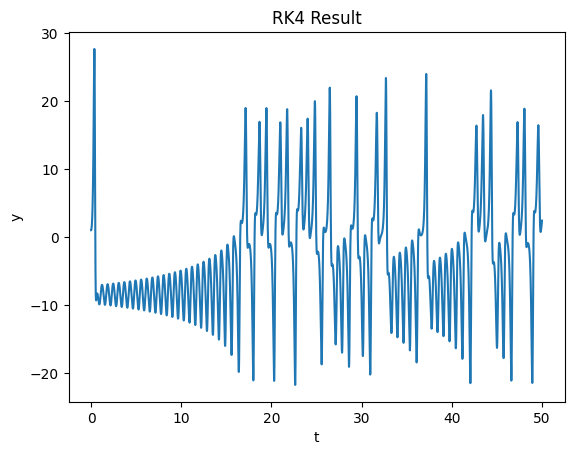

In [30]:
#initialize variables
sigma = 10
r = 28
b = 8 / 3
t_0 = 0
t_f = 50

x_0 = 0
y_0 = 1
z_0 = 0

step = 10000
h_new = (t_f - t_0) / step

#function for dx/dt
def dx(sigma, x, y):
    return sigma*(y-x)

#function for dy/dt
def dy(r, x, y, z):
    return r*x - y - x*z

#function for dz/dt
def dz(x, y, b, z):
    return x*y - b*z

#function for RK4 with multiple variables
def RK4_Lorenz(t_0, h, step, x0, y0, z0, sigma, r, b):
    #create solution array and initialize variables
    sol = [(t_0, x0, y0, z0)]

    t = t_0
    x = x0
    y = y0
    z = z0

    for _ in range(step+1):
        #complete the RK4 steps for each x, y, z
        k1x = h * dx(sigma, x, y)
        k1y = h * dy(r, x, y, z)
        k1z = h * dz(x, y, b, z)

        k2x = h * dx(sigma, x+0.5*k1x, y+0.5*k1y)
        k2y = h * dy(r, x+0.5*k1x, y+0.5*k1y, z+0.5*k1z)
        k2z = h * dz(x+0.5*k1x, y+0.5*k1y, b, z+0.5*k1z)

        k3x = h * dx(sigma, x+0.5*k2x, y+0.5*k2y)
        k3y = h * dy(r, x+0.5*k2x, y+0.5*k2y, z+0.5*k2z)
        k3z = h * dz(x+0.5*k2x, y+0.5*k2y, b, z+0.5*k2z) 

        k4x = h * dx(sigma, x+k3x, y+k3y)
        k4y = h * dy(r, x+k3x, y+k3y, z+k3z)
        k4z = h * dz(x+k3x, y+k3y, b, z+k3z)

        #update x, y, z values and t
        x += (k1x + 2*k2x + 2*k3x + k4x)/6   
        y += (k1y + 2*k2y + 2*k3y + k4y)/6
        z += (k1z + 2*k2z + 2*k3z + k4z)/6

        t += h
        sol.append((t, x, y, z))

    return sol

#get solution
s = RK4_Lorenz(t_0, h_new, step, x_0, y_0, z_0, sigma, r, b)

#extract the values for each variable
t = [i[0] for i in s]
x = [i[1] for i in s]
y = [i[2] for i in s]
z = [i[3] for i in s]

#plot the result of y as a function of time
plt.plot(t, y)
plt.xlabel("t")
plt.ylabel("y")
plt.title("RK4 Result")
plt.show()

Question 2b

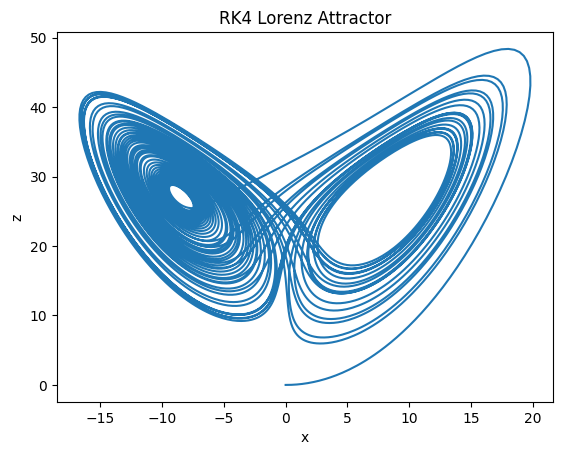

In [31]:
#plot z against x - butterfly plot
plt.plot(x, z)
plt.xlabel("x")
plt.ylabel("z")
plt.title("RK4 Lorenz Attractor")
plt.show()

Question 2c

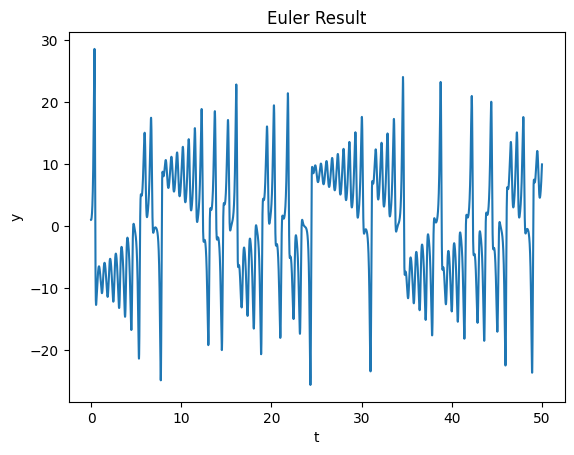

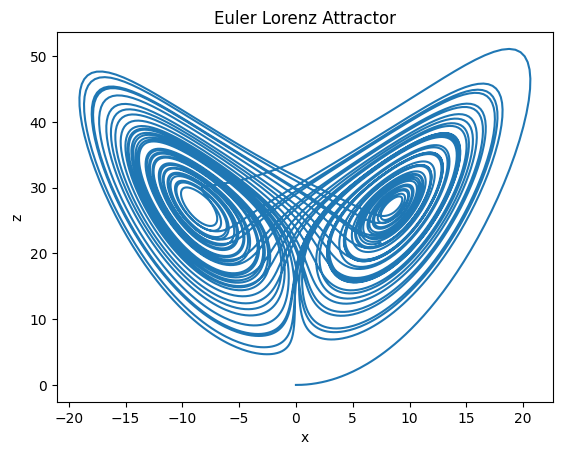

In [32]:
#function for Euler's method
def Euler_lorenz(t0, h, steps, x0, y0, z0, sigma, r, b):
    #initialize variables
    sol = [(t0, x0, y0, z0)]

    t = t0
    x = x0
    y = y0
    z = z0

    for _ in range(steps+1):

        dx_val = dx(sigma, x, y)
        dy_val = dy(r, x, y, z)
        dz_val = dz(x, y, b, z)
        #update x y and z using h
        x += h * dx_val
        y += h * dy_val
        z += h * dz_val

        t += h
        sol.append((t, x, y, z))

    return sol

s_euler = Euler_lorenz(t_0, h_new, step, x_0, y_0, z_0, sigma, r, b)

#extract the euler values
t_e = [i[0] for i in s_euler]
x_e = [i[1] for i in s_euler]
y_e = [i[2] for i in s_euler]
z_e = [i[3] for i in s_euler]

#overlap plot with RK4 result to compare
plt.plot(t_e, y_e)
plt.xlabel("t")
plt.ylabel("y")
plt.title("Euler Result")
plt.show()

#overlap plot with RK4 result to compare
plt.plot(x_e, z_e)
plt.xlabel("x")
plt.ylabel("z")
plt.title("Euler Lorenz Attractor")
plt.show()

The solutions look different as the Euler result is more erratic.

Question 3a - skip

Question 3b

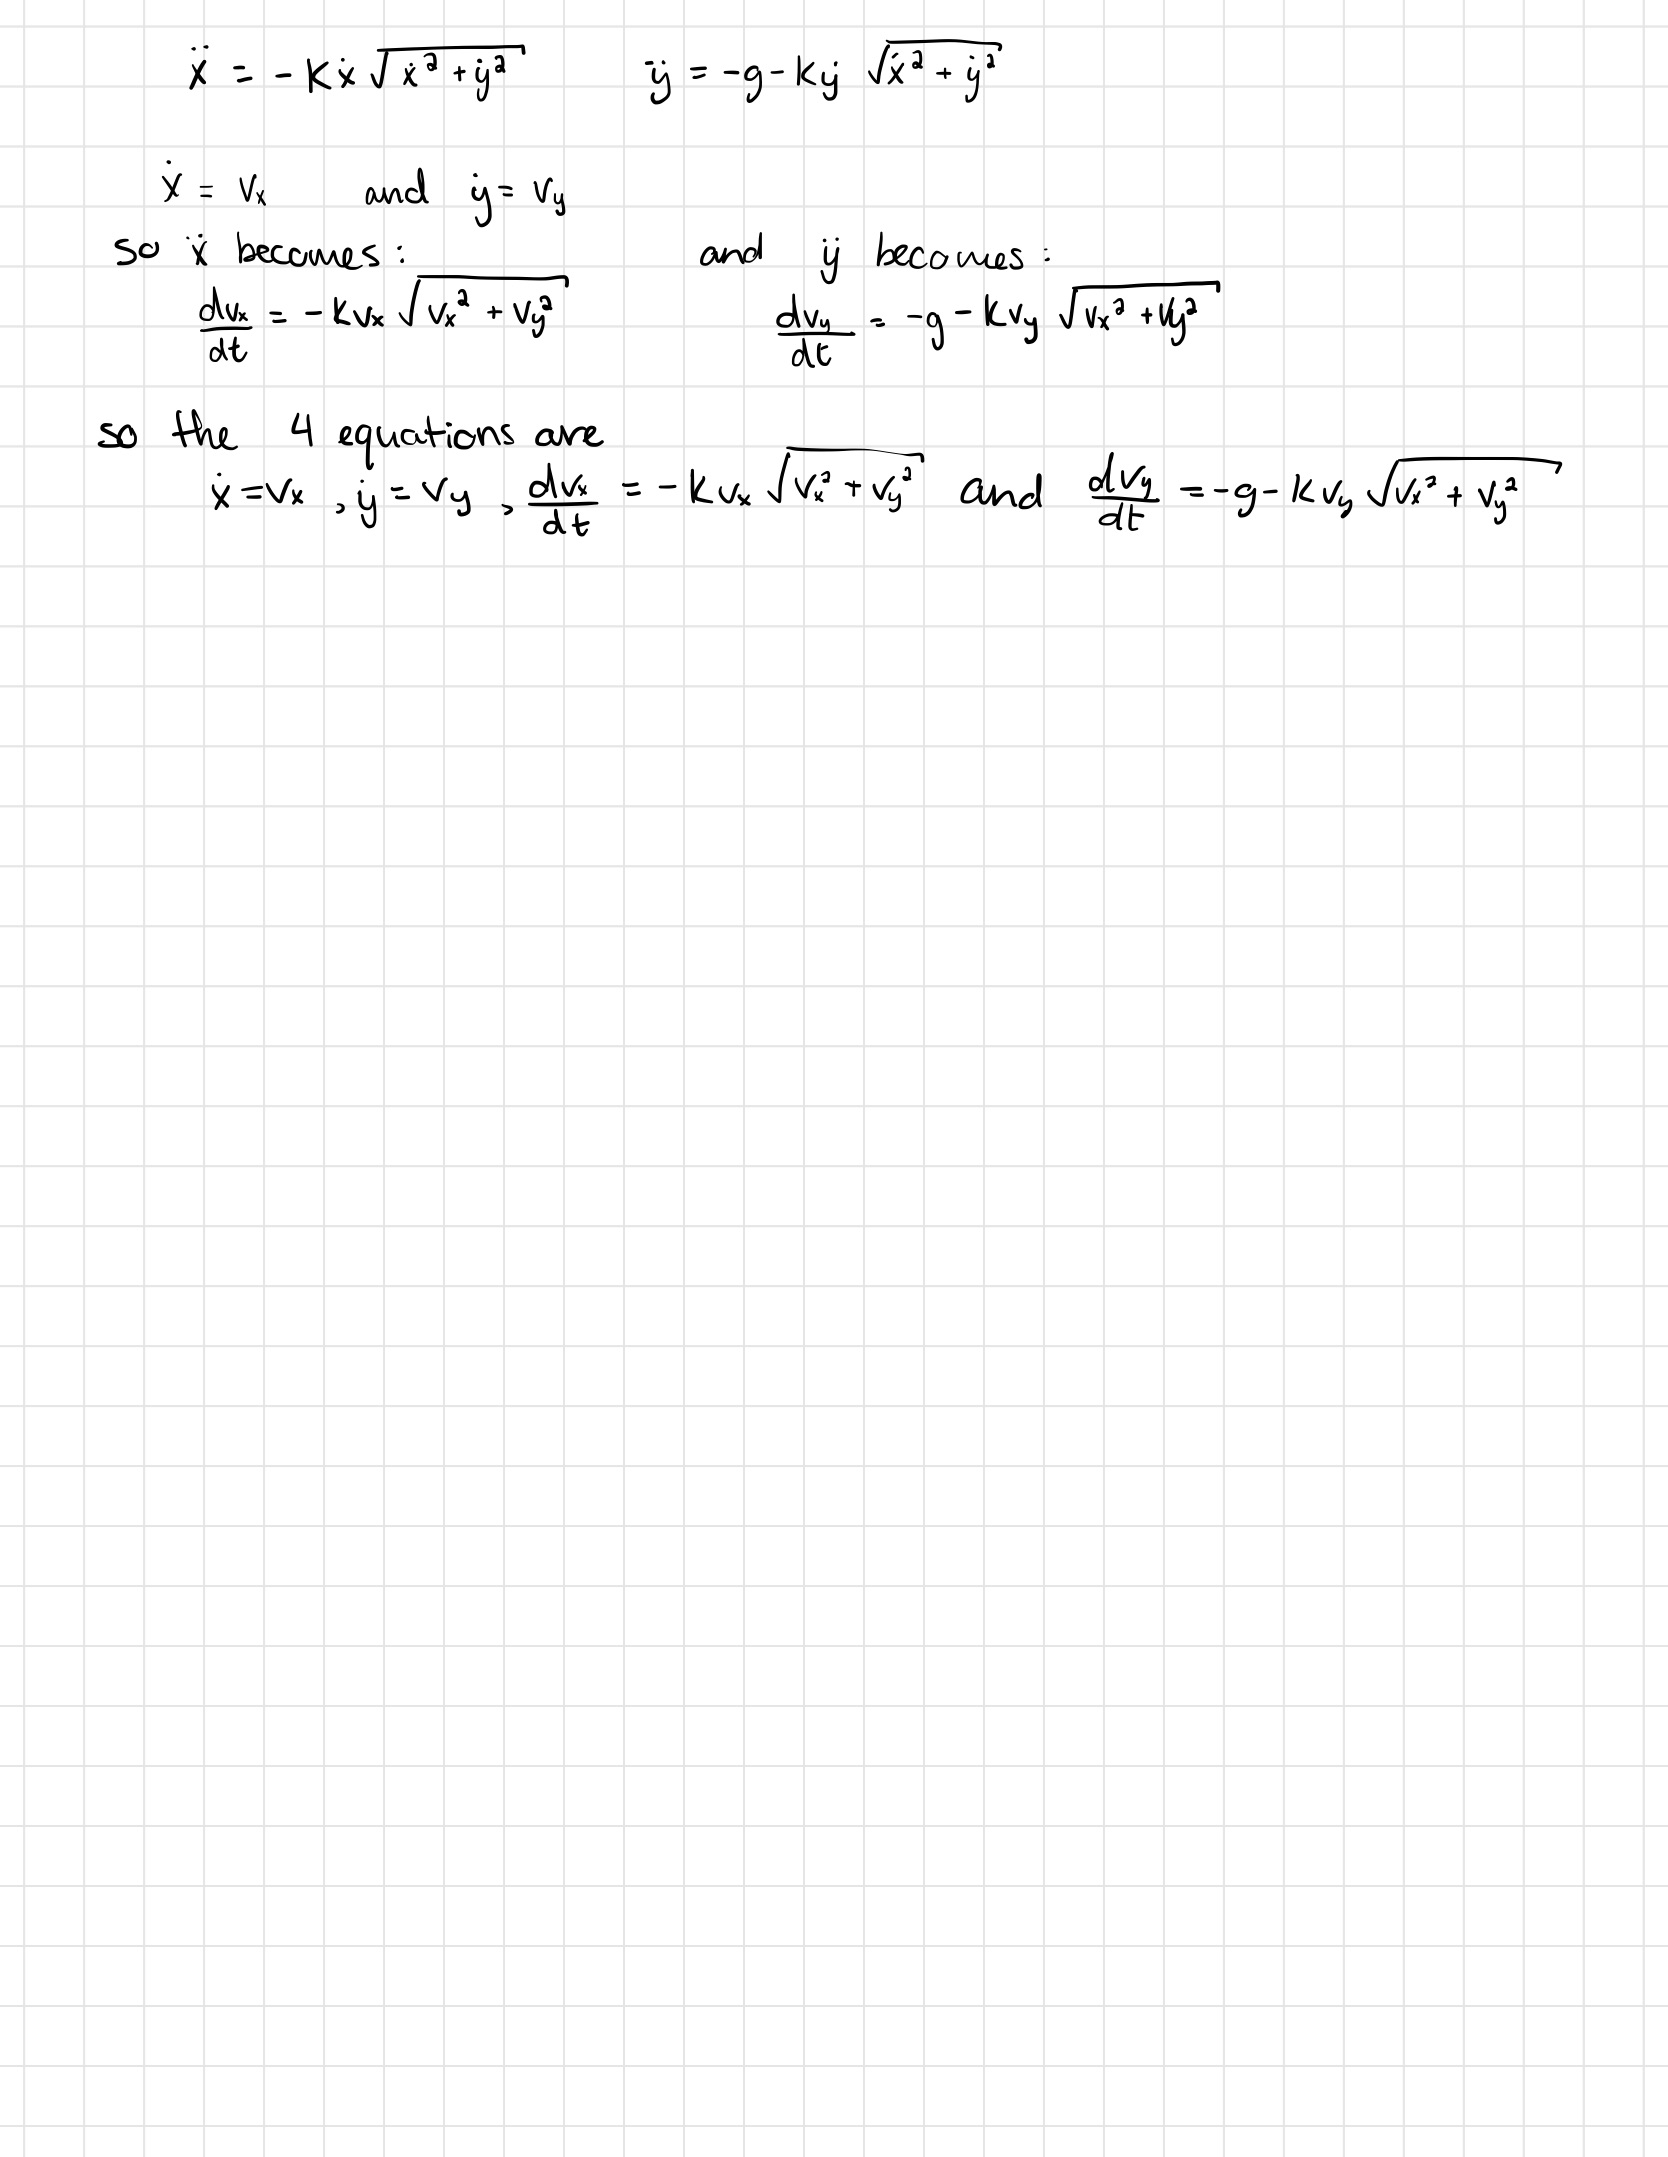

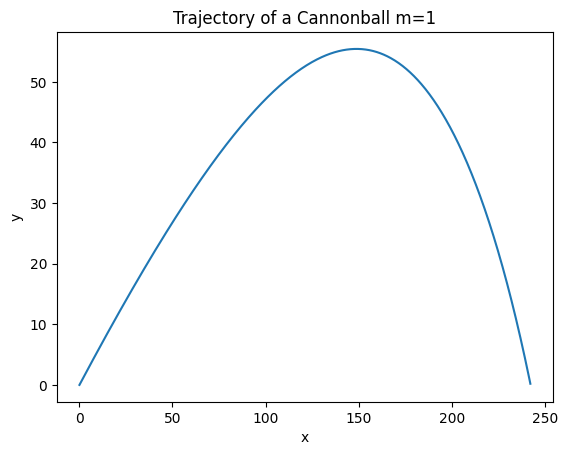

In [33]:
#function for simulating the cannonball
def simulate(m):
    #initialize constants
    g = 9.8
    R = 0.08
    ro = 1.22
    C = 0.47
    angle = np.deg2rad(30)

    #set a group of constants to a variable for easier calculations
    k = (np.pi * R**2 * ro * C)/ (2*m)

    #function for all 4 first order equations
    def f(t, Y):
        x, y, vx, vy = Y
        #square-rooted term to simplify calculations
        v = np.sqrt(vx**2 + vy**2)

        #the first order odes
        dxdt = vx
        dydt = vy
        dvxdt = -k * vx * v
        dvydt = -g - k * vy * v

        return np.array([dxdt, dydt, dvxdt, dvydt])
    
    #array of initial conditions
    Y = np.array([0, 0, 100*np.cos(angle), 100*np.sin(angle)])

    #stepsize and starting t
    dt = 0.01
    t = 0

    xs, ys = [], []

    #the RK4 method for this problem
    while Y[1] >= 0:
        xs.append(Y[0])
        ys.append(Y[1])

        k1 = f(t, Y)
        k2 = f(t + dt/2, Y + dt*k1/2)
        k3 = f(t + dt/2, Y + dt*k2/2)
        k4 = f(t + dt, Y + dt*k3)

        Y += (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        t += dt
    
    return xs, ys

mass = 1
#plot the trajectory of the cannonball
xs, ys = simulate(mass)
plt.plot(xs, ys)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of a Cannonball m=1")
plt.show()



Question 3c

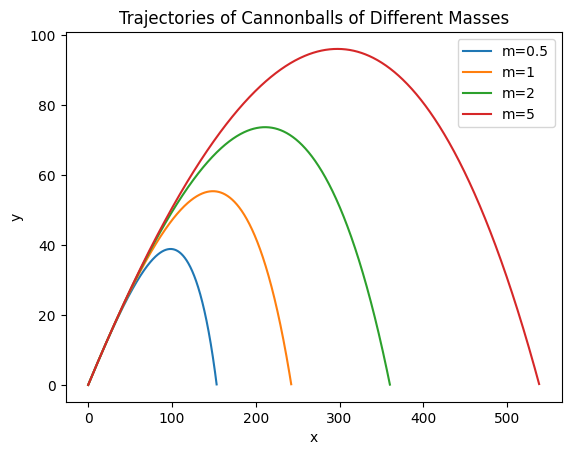

In [34]:
#series of cannon balls with different masses
masses = [0.5, 1, 2, 5]
#plot each trajectory
for m in masses:
    xs, ys = simulate(m)
    plt.plot(xs, ys, label=f"m={m}")

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectories of Cannonballs of Different Masses")
plt.show()

As the masses increase, the total distance in the x direction traveled by the cannonball increases. This is because the drag force term is inversely proportional to the mass, so heavier cannonballs have less deceleration due to air resistance. As a result, they maintain their velocity longer and travel further. THe trajectories also become higher and more similar to a parabolic path as mass increases

Question 4a

In [35]:
#constants
eV = 1.602e-19
V0 = 50 * eV #convert to Joules
a = 1e-11
hbar = 1.054e-34
m_e = 9.11e-31

x_cond = [-10*a, 10*a]
N = 10000
h = (x_cond[1] - x_cond[0])/N

#function for potential
def V(x):
    return V0 * x**2 / a**2

#function for the first order ODEs
def system(x, y, E):
    s, z = y
    #two first order equations
    ds = z
    dz = (2*m_e/hbar**2) * (V(x) - E) * s
    return np.array([ds, dz], float)

#RK4 for the Schrodinger equation
def RK4_Scrodinger(x, y, E):
    k1 = system(x, y, E)
    k2 = system(x + h/2, y + h*k1/2, E)
    k3 = system(x + h/2, y + h*k2/2, E)
    k4 = system(x + h, y + h*k3, E)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

#function to solve the problem using RK4
def solution(E):
    #set up initial conditions
    y = np.array([0.0, 1.0], float)
    x = x_cond[0]

    #get the range of values for inside the well
    xarr = np.arange(x, x_cond[1] + h, h)
    #array for the values of "s" as defined before for the first order equations
    sarr = np.zeros(len(xarr))
    sarr[0] = y[0]

    for i in range(1, len(xarr)):
        #solve using RK4
        y = RK4_Scrodinger(x, y, E)
        x += h
        sarr[i] = y[0]

    return xarr, sarr

#function to impose the boundary conditions of psi
def get(E):
    _, psi = solution(E)
    return psi[-1]

#Function for the secant method to find the energies
def secant(E1, E2):
    #bad initial guesses
    fa = get(E1)
    fb = get(E2)
    if fa * fb >= 0:
        print("Secant method failed")
        return
    
    a_n = E1
    b_n = E2

    for i in range(50):
        #get the next solution update
        m = a_n - fa * (b_n - a_n)/(fb - fa)
        f_m = get(m)

        #update values depending how close we are to the solution
        if fa*f_m < 0:
            fb  = f_m
            b_n = m 
        elif fb*f_m < 0:
            a_n = m
            fa = f_m
        elif abs(f_m) < 1e-10:
            #minimum found
            return m
        else:
            #Could not converge
            print("Secant method failed")
            return None
        
        if abs(b_n - a_n) < 1e-3 * eV:
            break
    #converged as small as possible
    return m

#use numbers close to the expected numbers given in the assignment as guesses
#all converted to Joules to work with the equations
E0 = secant(130*eV, 170*eV)
E1 = secant(350*eV, 450*eV)
E2 = secant(650*eV, 750*eV)

#print out and convert back to eV
print("E0 (ground state): ", E0/eV) #around 150 eV
print("E1: ", E1/eV) #around 400 eV
print("E2: ", E2/eV) #around 700 eV

#check the spacing to see if they are equal
print("The spacing between E1 and E0 is: ", (E1-E0)/eV)
print("The spacing between E2 and E1 is: ", (E2-E1)/eV)

E0 (ground state):  137.94951275029814
E1:  413.84853825095894
E2:  689.7475637524617
The spacing between E1 and E0 is:  275.8990255006608
The spacing between E2 and E1 is:  275.8990255015027


Question 4b

In [36]:

#new V(x)
def V2(x):
    return V0*x**4/a**4

#function for the first order ODEs
def system(x, y, E):
    s, z = y
    #two first order equations
    ds = z
    dz = (2*m_e/hbar**2) * (V2(x) - E) * s
    return np.array([ds, dz], float)

#RK4 for the Schrodinger equation
def RK4_Scrodinger2(x, y, E):
    k1 = system(x, y, E)
    k2 = system(x + h/2, y + h*k1/2, E)
    k3 = system(x + h/2, y + h*k2/2, E)
    k4 = system(x + h, y + h*k3, E)
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

#function to solve the problem using RK4
def solution2(E, x_arr, parity):
    #set up initial conditions
    if parity == "odd":
        y = np.array([0.0, 1.0], float)
    else:
        y = np.array([1.0, 0.0], float)

    x = x_arr[0]

    #get the range of values for inside the well
    xarr = np.arange(x, x_arr[1] + h, h)
    #array for the values of "s" as defined before for the first order equations
    sarr = np.zeros(len(xarr))
    sarr[0] = y[0]

    for i in range(1, len(xarr)):
        #solve using RK4
        y = RK4_Scrodinger2(x, y, E)
        x += h
        sarr[i] = y[0]

    return xarr, sarr

#function to impose the boundary conditions of psi
def get2(E, parity):
    _, psi = solution2(E, x_cond, parity)
    return psi[-1]

#Function for the secant method to find the energies
def secant2(E1, E2, parity):
    #set up boundary conditions for psi
    psi1 = get2(E1, parity)
    psi2 = get2(E2, parity)
    tol = 1e-6 * eV # small tolerance for convergence

    while abs(E2 - E1) > tol:

        if psi2 == psi1:
            break # avoid division by 0

        E_new = E2 - psi2 * (E2 - E1) / (psi2 - psi1)

        #update energy values and boundary conditions
        E1, psi1 = E2, psi2
        E2 = E_new
        psi2 = get2(E2, parity)

    return E2

E0_new = secant2(150*eV, 250*eV, "even")
E1_new = secant2(700*eV, 800*eV, "odd")
E2_new = secant2(1400*eV, 1500*eV, "even")

print("E0 (ground state): ", E0_new/eV) #around 200 eV
print("E1: ", E1_new/eV) #around 750 eV
print("E2: ", E2_new/eV) #around 1450 eV (corrected)

print("The spacing between E1 and E0 is: ", (E1_new-E0_new)/eV)
print("The spacing between E2 and E1 is: ", (E2_new-E1_new)/eV) # no longer even because the function is no longer quadratic

E0 (ground state):  205.15924194261694
E1:  735.1621162431227
E2:  1442.5311418058125
The spacing between E1 and E0 is:  530.0028743005057
The spacing between E2 and E1 is:  707.3690255626898


Question 4c

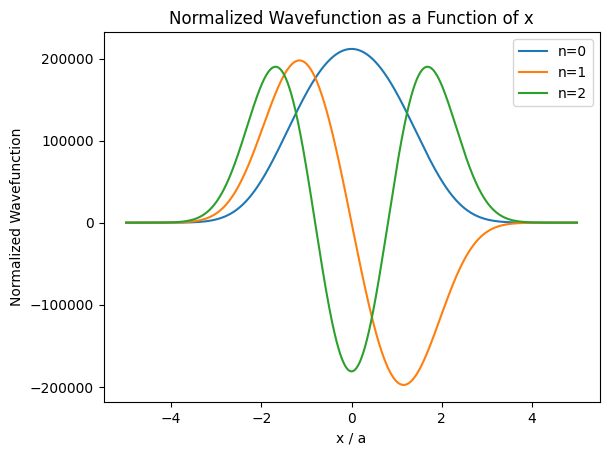

In [37]:
#define a new x range
x_arr_c = [-5*a, 5*a]

#function to normalize the wavefunction
def normalize(x, psi):
    dx = x[1] - x[0]
    integral = np.sum(psi**2) * dx
    return psi / np.sqrt(integral)

#get the get the wavefunction
x_E0, psi0 = solution2(E0_new, x_arr_c, "even")
x_E1, psi1 = solution2(E1_new, x_arr_c, "odd")
x_E2, psi2 = solution2(E2_new, x_arr_c, "even")

#normalize the wavefunction
psi0 = normalize(x_E0, psi0)
psi1 = normalize(x_E1, psi1)
psi2 = normalize(x_E2, psi2)

#plot the data
plt.plot(x_E0/(a), psi0, label="n=0")
plt.plot(x_E1/(a), psi1, label="n=1")
plt.plot(x_E2/(a), psi2, label="n=2")

plt.xlabel("x / a")
plt.ylabel("Normalized Wavefunction")
plt.title("Normalized Wavefunction as a Function of x")
plt.legend()
plt.show()
